In [3]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score,
)

2.Load dataset


In [4]:
df = pd.read_csv(r"C:\Users\manis\Ginger_Gradient\clinical-intelligence-system\conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv"
)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (273, 20)


,Unnamed: 0,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


3.Exploratory data analysis

In [5]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               273 non-null    int64  
 1   Gender                   273 non-null    int64  
 2   Age                      273 non-null    int64  
 3   Schooling                272 non-null    float64
 4   Breastfeeding            273 non-null    int64  
 5   Varicella                273 non-null    int64  
 6   Initial_Symptom          272 non-null    float64
 7   Mono_or_Polysymptomatic  273 non-null    int64  
 8   Oligoclonal_Bands        273 non-null    int64  
 9   LLSSEP                   273 non-null    int64  
 10  ULSSEP                   273 non-null    int64  
 11  VEP                      273 non-null    int64  
 12  BAEP                     273 non-null    int64  
 13  Periventricular_MRI      273 non-null    int64  
 14  Cortical_MRI             2

In [13]:
numerical_features = [
     "Age",
    "Schooling",
    "Initial_EDSS",
    "Final_EDSS"
]

categorical_features = [
    "Gender",
    "Breastfeeding",
    "Varicella",
    "Initial_Symptom",
    "Mono_or_Polysymptomatic",
    "Oligoclonal_Bands",
    "LLSSEP",
    "ULSSEP",
    "VEP",
    "BAEP",
    "Periventricular_MRI",
    "Cortical_MRI",
    "Infratentorial_MRI",
    "Spinal_Cord_MRI"
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Schooling', 'Initial_EDSS', 'Final_EDSS']
Categorical features: ['Gender', 'Breastfeeding', 'Varicella', 'Initial_Symptom', 'Mono_or_Polysymptomatic', 'Oligoclonal_Bands', 'LLSSEP', 'ULSSEP', 'VEP', 'BAEP', 'Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI']


In [6]:
# missing values
df.isna().sum().sort_values()

Unnamed: 0                   0
Spinal_Cord_MRI              0
Infratentorial_MRI           0
Cortical_MRI                 0
Periventricular_MRI          0
BAEP                         0
VEP                          0
ULSSEP                       0
LLSSEP                       0
Mono_or_Polysymptomatic      0
Varicella                    0
Breastfeeding                0
Age                          0
Gender                       0
Oligoclonal_Bands            0
group                        0
Initial_Symptom              1
Schooling                    1
Final_EDSS                 148
Initial_EDSS               148
dtype: int64

In [7]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Unnamed: 0
0      1
180    1
186    1
185    1
184    1
183    1
182    1
181    1
179    1
137    1
Name: count, dtype: int64
Gender
2    168
1    105
Name: count, dtype: int64
Age
28    16
24    15
34    14
38    11
40    11
29    11
36    11
22    10
31    10
35     9
Name: count, dtype: int64
Schooling
20.0    83
15.0    81
12.0    59
9.0     34
22.0     4
6.0      3
25.0     2
14.0     2
0.0      1
23.0     1
Name: count, dtype: int64
Breastfeeding
1    131
3     85
2     57
Name: count, dtype: int64
Varicella
1    124
2    104
3     45
Name: count, dtype: int64
Initial_Symptom
8.0     39
3.0     32
1.0     31
4.0     30
2.0     26
6.0     17
10.0    15
14.0    14
5.0     13
15.0    11
Name: count, dtype: int64
Mono_or_Polysymptomatic
2    186
1     81
3      6
Name: count, dtype: int64
Oligoclonal_Bands
0    186
1     76
2     11
Name: count, dtype: int64
LLSSEP
0    157
1    116
Name: count, dtype: int64
ULSSEP
0    172
1    101
Name: count, dtype: int64
VEP
0    189
1     84
Na

In [8]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


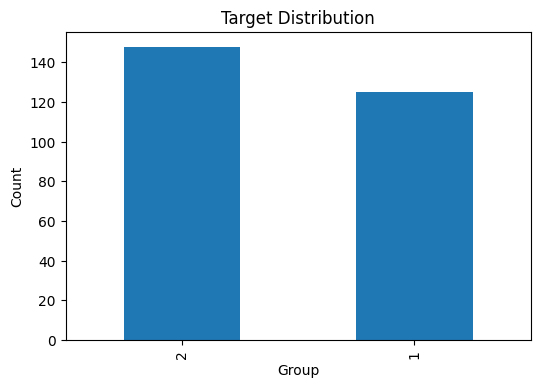


Class Distribution (%)
group
2    54.212454
1    45.787546
Name: proportion, dtype: float64


In [ ]:
# visualize target distribution
plt.figure(figsize=(6,4))
df["group"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

print("\nClass Distribution (%)")
print(df["group"].value_counts(normalize=True)*100)

In [11]:
df["group"] = df["group"].map({1:0, 2:1})

In [12]:
print(df["group"].value_counts())

group
1    148
0    125
Name: count, dtype: int64


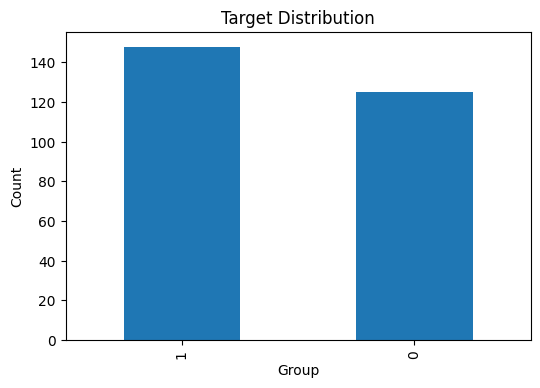


Class Distribution (%)
group
1    54.212454
0    45.787546
Name: proportion, dtype: float64


In [14]:
# visualize target distribution
plt.figure(figsize=(6,4))
df["group"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

print("\nClass Distribution (%)")
print(df["group"].value_counts(normalize=True)*100)

Balanced dataset

In [15]:
df[numerical_features].describe()

,Age,Schooling,Initial_EDSS,Final_EDSS
count,273.000000,272.000000,125.000000,125.00000
mean,34.062271,15.176471,1.360000,1.44800
std,11.114369,4.244175,0.587504,0.65323
min,15.000000,0.000000,1.000000,1.00000
25%,25.000000,12.000000,1.000000,1.00000
50%,33.000000,15.000000,1.000000,1.00000
75%,40.000000,20.000000,2.000000,2.00000
max,77.000000,25.000000,3.000000,3.00000


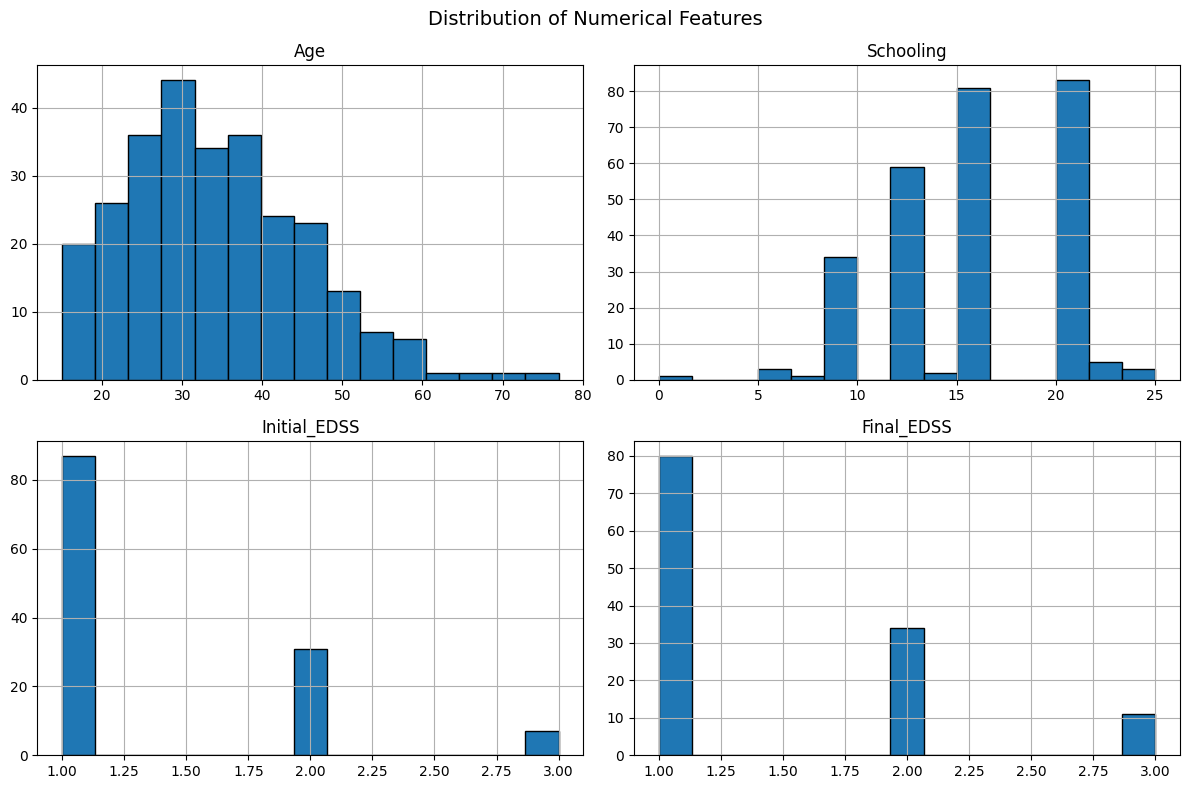

In [17]:
import matplotlib.pyplot as plt

# Numerical columns
numerical_features = [
    "Age",
    "Schooling",
    "Initial_EDSS",
    "Final_EDSS"
]

# Create histograms
df[numerical_features].hist(
    figsize=(12,8),
    bins=15,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

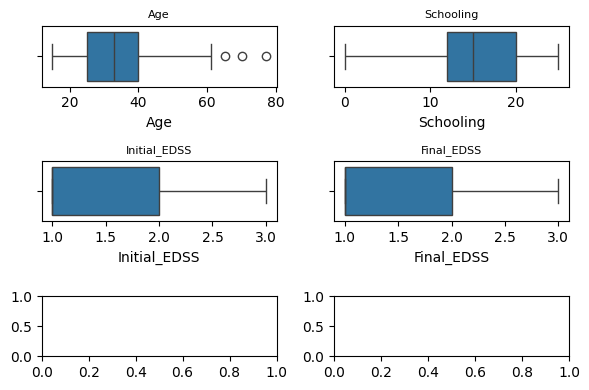

In [19]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 2, figsize=(6, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

No much outliers,we can leave as it is.

In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\manis\Ginger_Gradient\clinical-intelligence-system\conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv"
)

print(df.shape)
df.head()

(273, 20)


,Unnamed: 0,Gender,Age,Schooling,Breastfeeding,Varicella,Initial_Symptom,Mono_or_Polysymptomatic,Oligoclonal_Bands,LLSSEP,ULSSEP,VEP,BAEP,Periventricular_MRI,Cortical_MRI,Infratentorial_MRI,Spinal_Cord_MRI,Initial_EDSS,Final_EDSS,group
0,0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


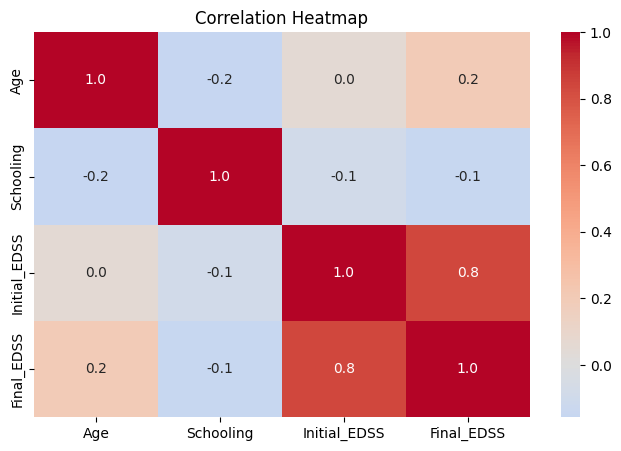

In [ ]:
# identify presence of highly correlated columns & feature relationships
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.heatmap(
    df[numerical_features].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

Initial_EDSS and Final_EDSS are highly correlated (r = 0.80).

In [ ]:
4. Data preprocessing

In [11]:
# Separate X and y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Create a signature for each feature row - to prevent duplicates flow to test set
row_signature = pd.util.hash_pandas_object(X, index=False)

In [16]:
# Split data into train and test sets using GroupShuffleSplit
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=row_signature)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (232, 18)
Test shape: (41, 18)


In [17]:
print("Dataset size", X.shape)
print("Train Dataset size", X_train.shape)
print("Test Dataset size", X_test.shape)

Dataset size (273, 18)
Train Dataset size (232, 18)
Test Dataset size (41, 18)


5.Baseline Model-Logistic Regression

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("model", LogisticRegression())
])

In [7]:
from sklearn.model_selection import train_test_split

# Target column
TARGET_COL = "group"

# Features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'df' is not defined

In [6]:
# training the base pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

base_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LogisticRegression(max_iter=1000))
])

base_pipe.fit(X_train, y_train)


NameError: name 'X_train' is not defined